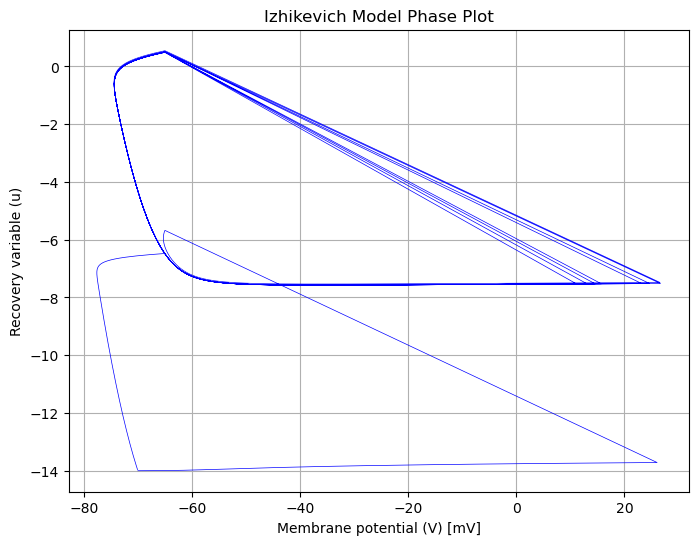

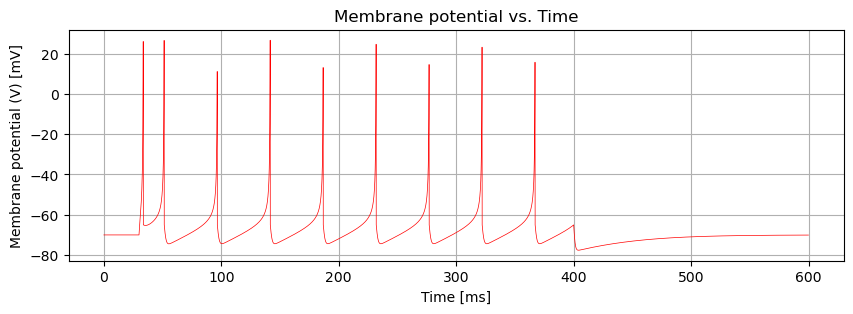

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Izhikevich模型参数
a = 0.02  # 恢复变量的时间常数
b = 0.2   # 控制恢复变量的影响
c = -65   # 膜电位重置值
d = 8     # 恢复变量重置值
I0 = 10   # 外部电流 (μA/cm²)，在指定的时间段内施加
t_begin = 30  # 外部电流开始时间 (ms)
t_end = 400   # 外部电流结束时间 (ms)

# Izhikevich模型方程
def izhikevich(v, u, I):
    dvdt = 0.04 * v**2 + 5 * v + 140 - u + I
    dudt = a * (b * v - u)
    return dvdt, dudt

# 外部电流的函数形式 (方波电流)
def external_current(t):
    return I0 if t_begin <= t <= t_end else 0  # 方波电流

# 初始化参数
v = -70  # 初始膜电位 (mV)
u = b * v  # 初始恢复变量
time_step = 0.1  # 时间步长 (ms)
t_max = 600  # 模拟的总时间 (ms)
t = np.arange(0, t_max, time_step)

# 结果存储
v_values = []
u_values = []
I_values = []

# Izhikevich模型求解
for tt in t:
    I = external_current(tt)  # 获取当前电流刺激
    dvdt, dudt = izhikevich(v, u, I)  # 计算膜电位和恢复变量的变化率
    v += dvdt * time_step  # 更新膜电位
    u += dudt * time_step  # 更新恢复变量
    
    # 检查膜电位是否超过阈值，产生动作电位
    if v >= 30:
        v = c  # 膜电位重置
        u += d  # 恢复变量增加

    # 保存数据
    v_values.append(v)
    u_values.append(u)
    I_values.append(I)

# 绘制相图 (V vs. u)
plt.figure(figsize=(8, 6))
plt.plot(v_values, u_values, lw=0.5, color='blue')
plt.title('Izhikevich Model Phase Plot')
plt.xlabel('Membrane potential (V) [mV]')
plt.ylabel('Recovery variable (u)')
plt.grid(True)
plt.show()

# 绘制膜电位随时间变化的图像
plt.figure(figsize=(10, 3))
plt.plot(t, v_values, lw=0.5, color='red')
plt.title('Membrane potential vs. Time')
plt.xlabel('Time [ms]')
plt.ylabel('Membrane potential (V) [mV]')
plt.grid(True)
plt.show()


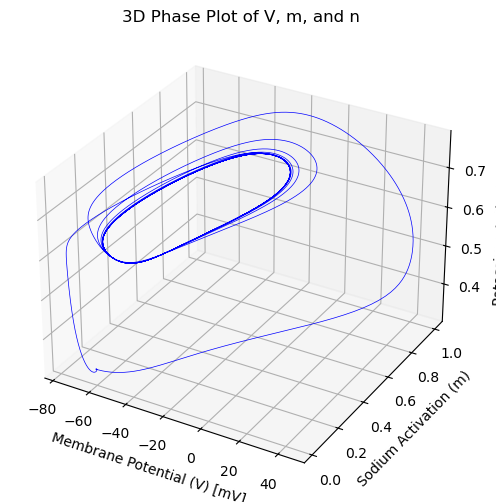

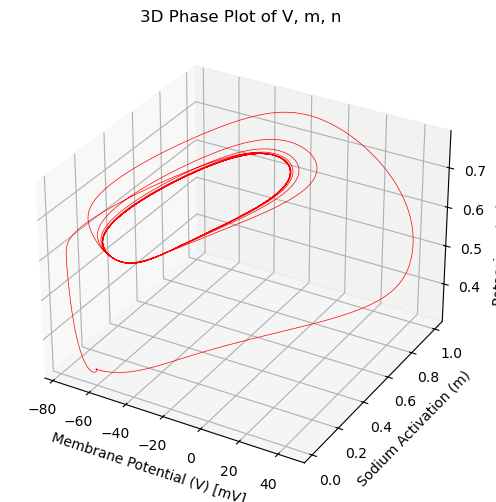

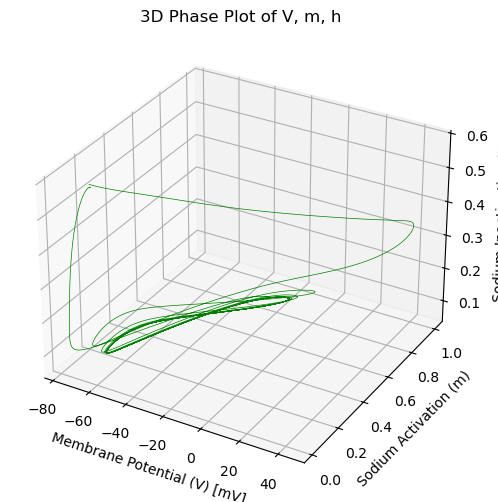

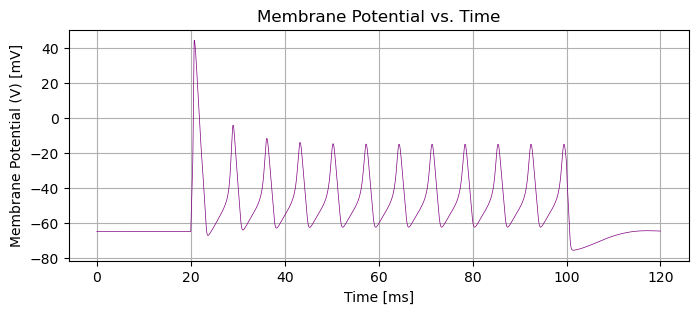

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from mpl_toolkits.mplot3d import Axes3D

# HH方程参数定义
C_m = 0.01  # 膜电容（单位：μF/cm²）
g_Na = 1.2  # 钠离子通道最大电导（单位：mS/cm²）
g_K = 0.36  # 钾离子通道最大电导（单位：mS/cm²）
g_L = 0.003  # 漏电流通道最大电导（单位：mS/cm²）
E_Na = 50.0  # 钠离子反转电位（单位：mV）
E_K = -77.0  # 钾离子反转电位（单位：mV）
E_L = -54.387  # 漏电流反转电位（单位：mV）
V_rest = -65.0  # 静息电位（单位：mV）

# 钠离子通道激活变量m的速率常数
def alpha_m(V):
    return 0.1 * (V+40.0) / (1.0 - np.exp(-(V +40.0) / 10.0))

def beta_m(V):
    return 4.0 * np.exp(-0.0556*(V +65.0))

# 钠离子通道失活变量h的速率常数
def alpha_h(V):
    return 0.07 * np.exp(-(V +65.0) / 20.0)

def beta_h(V):
    return 1.0 / (1.0 + np.exp(-(V + 35.0) / 10.0))

# 钾离子通道激活变量n的速率常数
def alpha_n(V):
    return 0.01 * (V + 55.0) / (1.0 - np.exp(-(V + 55.0) / 10.0))

def beta_n(V):
    return 0.125 * np.exp(-(V + 65.0) / 80.0)

# 平衡态的门控变量（当dm/dt=0, dh/dt=0, dn/dt=0时的值）
def m_inf(V):
    return alpha_m(V) / (alpha_m(V) + beta_m(V))

def h_inf(V):
    return alpha_h(V) / (alpha_h(V) + beta_h(V))

def n_inf(V):
    return alpha_n(V) / (alpha_n(V) + beta_n(V))

# 门控变量的时间常数
def tau_m(V):
    return 1.0 / (alpha_m(V) + beta_m(V))

def tau_h(V):
    return 1.0 / (alpha_h(V) + beta_h(V))

def tau_n(V):
    return 1.0 / (alpha_n(V) + beta_n(V))

# 外部电流的函数形式 (方波电流)
def external_current(t):
    I0 = 0.9
    t_begin = 20  # 外部电流开始时间 (ms)
    t_end = 100   # 外部电流结束时间 (ms)
    return I0 if t_begin <= t <= t_end else 0

# HH方程的ODE系统
def hh_ode(y, t):
    V, m, h, n = y
    dm_dt = (m_inf(V) - m) / tau_m(V)
    dh_dt = (h_inf(V) - h) / tau_h(V)
    dn_dt = (n_inf(V) - n) / tau_n(V)
    
    # 膜电位的变化率
    I = external_current(t)
    dV_dt = (I + g_Na * m**3 * h * (E_Na - V) + g_K * n**4 * (E_K - V) + g_L * (E_L - V)) / C_m
    
    return [dV_dt, dm_dt, dh_dt, dn_dt]

# 初始条件设置
V0 = V_rest  # 初始膜电位为静息电位
m0 = m_inf(V0)  # 初始m为平衡态
h0 = h_inf(V0)  # 初始h为平衡态
n0 = n_inf(V0)  # 初始n为平衡态

y0 = [V0, m0, h0, n0]  # 初始状态向量

# 时间向量设置
t = np.linspace(0, 120, 10001)  # 模拟时间从0到120ms，10001个时间点

# 使用odeint求解微分方程
sol = odeint(hh_ode, y0, t)

# 提取膜电位V、钠激活变量m、钾激活变量n和钠失活变量h
V = sol[:, 0]
m = sol[:, 1]
h = sol[:, 2]
n = sol[:, 3]

# 创建第一个图：关于V, m, n的三维相图
fig1 = plt.figure(figsize=(10, 6))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.plot(V, m, n, lw=0.5, color='blue')
ax1.set_title('3D Phase Plot of V, m, and n')
ax1.set_xlabel('Membrane Potential (V) [mV]')
ax1.set_ylabel('Sodium Activation (m)')
ax1.set_zlabel('Potassium Activation (n)')
plt.show()

# 创建第二个图：关于V, m, n, h的四维相图
fig2 = plt.figure(figsize=(10, 6))
ax2 = fig2.add_subplot(111, projection='3d')
ax2.plot(V, m, n, lw=0.5, color='red')
ax2.set_title('3D Phase Plot of V, m, n')
ax2.set_xlabel('Membrane Potential (V) [mV]')
ax2.set_ylabel('Sodium Activation (m)')
ax2.set_zlabel('Potassium Activation (n)')

# 第二张四维相图（V, m, n, h）
fig3 = plt.figure(figsize=(10, 6))
ax3 = fig3.add_subplot(111, projection='3d')
ax3.plot(V, m, h, lw=0.5, color='green')
ax3.set_title('3D Phase Plot of V, m, h')
ax3.set_xlabel('Membrane Potential (V) [mV]')
ax3.set_ylabel('Sodium Activation (m)')
ax3.set_zlabel('Sodium Inactivation (h)')
plt.show()

# 创建膜电位关于时间的图
fig4 = plt.figure(figsize=(8, 3))
ax4 = fig4.add_subplot(111)
ax4.plot(t, V, lw=0.5, color='purple')  # 绘制膜电位随时间的变化
ax4.set_title('Membrane Potential vs. Time')
ax4.set_xlabel('Time [ms]')
ax4.set_ylabel('Membrane Potential (V) [mV]')
ax4.grid(True)  # 添加网格以便观察
plt.show()


